# Introduction to Jupyter Notebooks: Best Practices

**Course:** Computational BME  
**Author:** Sarah Groves, adapted by Lavie Ngo for Fall 2026

**Generative AI Usage Statement**: This notebook was developed using code from ChatGPT-4 on January 6, 2026. ChatGPT-4 was used to help generate example code.


### Project Goal
This notebook is set up to demonstrate a high-quality Jupyter notebook report and can be used as a **high-quality reference** when writing your own notebook reports. You can compare this notebook to `low_quality_notebook.ipynb.` 

The goal is not just to get correct output, but to write ***clear, reliable,
professional code*** that can be shared. Jupyter notebooks allow you to *tell a story* so the reader can understand why you executed the code you did.


## 1. Reading in example data from `pandas`

We will use the Python package `pandas` to make a dataframe of example data. The data can be read with the `pandas` package. 

### 1a. Import packages & set-up

In [1]:
# Import standard libraries
# Make sure the libraries are downloaded using pip/conda before importing
import pandas as pd
import matplotlib.pyplot as plt

# Improve plot appearance
plt.rcParams['figure.figsize'] = (8, 5)

### 1b. Load example data from a website

In [2]:
# Load an example dataset from pandas
df = pd.read_csv(
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
)

# Look at the first few rows only
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


Notice that we **avoid printing the entire dataset**.

Instead, we use the `.head()` method to focus on:
- Column names
- A few representative rows
- High-level summaries

### 1c. Load example data from a downloaded file from your computer
- In this class you may download datasets to your computer. When importing, it is best practice to provide the **entire** path so that the pd.read_csv() function knows where your file is located.


In [ ]:
df_example = pd.read_csv("example_data.xlsx") # Loading this file may throw a 'file not found' error because VSCode thinks it should be in the same directory as this notebook.


FileNotFoundError: [Errno 2] No such file or directory: 'example_data.xlsx'

In [4]:
df_example = pd.read_csv("/Users/lln5zuj/Library/CloudStorage/OneDrive-UniversityofVirginia/Graduate School/BME 2315 Fall 2026/Module 0/Lecture 3/example_data.csv") # Include the entire path of this file like this

df_example.head() # View the file

,Day,Temperature (Celsius)
0,Monday,-5
1,Tuesday,20
2,Wednesday,13
3,Thursday,7
4,Friday,28


### 1d. Load a function from a separate .py file into this notebook
- If you create functions that are outside of this notebook that you want to import into this notebook, you should have that script in the same directory as this notebook so VSCode can find it.

In [5]:
# Import a function from another .py file. Make sure the file is in the same directory as this notebook.
from example_function import convertCtoF # syntax: from "file_name", import "function_name"

# Call this function in this notebook.
temp_C = 20
temp_F = convertCtoF(temp_C)
print(f"{temp_C} degrees Celsius is equal to {temp_F} degrees Fahrenheit.")

20 degrees Celsius is equal to 68.0 degrees Fahrenheit.


### 1e. Cleaning missing data

In [6]:
# Drop rows with missing values in columns we care about
clean_df = df.dropna(subset=['bill_length_mm', 'bill_depth_mm'])

## 2. Plotting with Jupyter Notebooks

We will use matplotlib to plot the relationship between different variables in the penguin dataset.

### 2a. A Simple Scatter Plot

A good plot:
- Answers a specific question
- Has labeled axes
- Avoids unnecessary decoration

Here, we examine the relationship between bill length and bill depth.

In [4]:
plt.scatter(
    clean_df['bill_length_mm'],
    clean_df['bill_depth_mm'],
    alpha=0.7
)

plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.title('Penguin Bill Length vs Bill Depth')

plt.show()

NameError: name 'plt' is not defined

<div class="alert alert-block alert-success">
<b>Conclusions so far:</b>  It seems like there may be some distinct groups of penguins based on their bill depths and lengths. Could penguin species help explain the differences?
</div>

*(Notice that the above green box was made using HTML code directly in a markdown cell!)*

### 2b. Grouped Comparisons

Sometimes we want to compare distributions across categories.

We can ask (and answer with a plot) the following question:
> How does bill length differ across penguin species?

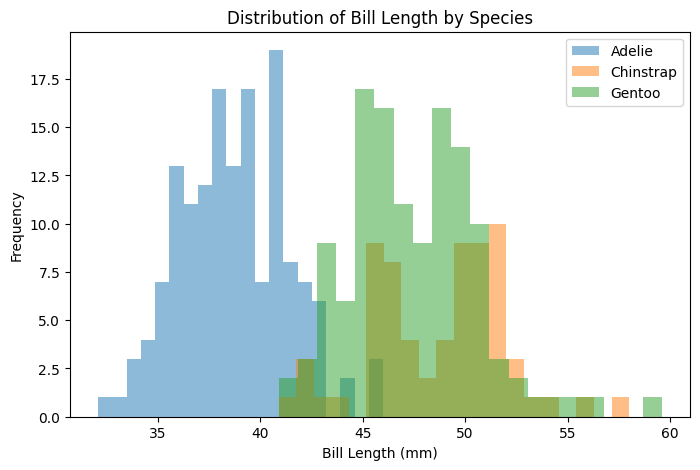

In [ ]:
# Group data by species
species = clean_df['species'].unique()

for sp in species:
    subset = clean_df[clean_df['species'] == sp]
    plt.hist(subset['bill_length_mm'], bins=20, alpha=0.5, label=sp)

plt.xlabel('Bill Length (mm)')
plt.ylabel('Frequency')
plt.title('Distribution of Bill Length by Species')
plt.legend()

plt.show()

## 3. Conclusions

Even with a small dataset and simple tools, we can:
- Tell a clear story
- Make thoughtful visualizations
- Keep notebooks readable and professional

**Key takeaways from data:**
> We see a lot of variation in bill length and depth, which might be explained by penguin species.

> Adelie penguins have much shorter bills than CHinstrap and Gentoo penguins.